<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/Lab3_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Exploring optimisatin of analytic functions

In [34]:
import torch
import math

def rastring2D(x, a=10):
  return (x * x - a * torch.cos(2*math.pi*x) + a).sum(0)

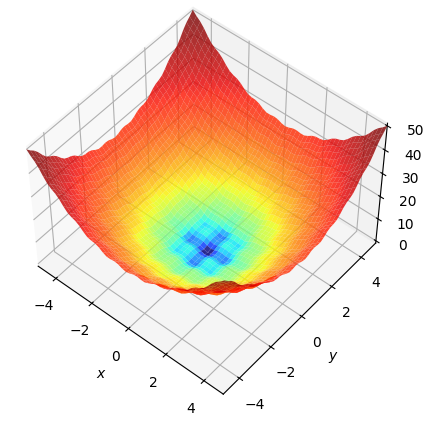

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm



xmin, xmax, xstep = -5, 5, .2
ymin, ymax, ystep = -5, 5, .2
x, y = np.meshgrid(np.arange(xmin, xmax + xstep, xstep), np.arange(ymin, ymax + ystep, ystep))
z = rastring2D(torch.tensor([x, y]), 0.5).numpy()

fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection='3d', elev=50, azim=-50)
ax.plot_surface(x, y, z, norm=LogNorm(), rstride=1, cstride=1,
                edgecolor='none', alpha=.8, cmap=plt.cm.jet)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

plt.show()

In [36]:
import torch

def optimise_with(optimiser_recipe, num_epochs=100):

  value_history = []
  path = []

  x = torch.tensor([5.0, 4.0], requires_grad=True)

  optimiser = optimiser_recipe([x])

  for i in range(num_epochs):
    optimiser.zero_grad()
    output = rastring2D(x, 0.5)
    output.backward()
    optimiser.step()
    value_history.append(output.data.item())
    path.append(x.data.tolist())

  return value_history, path

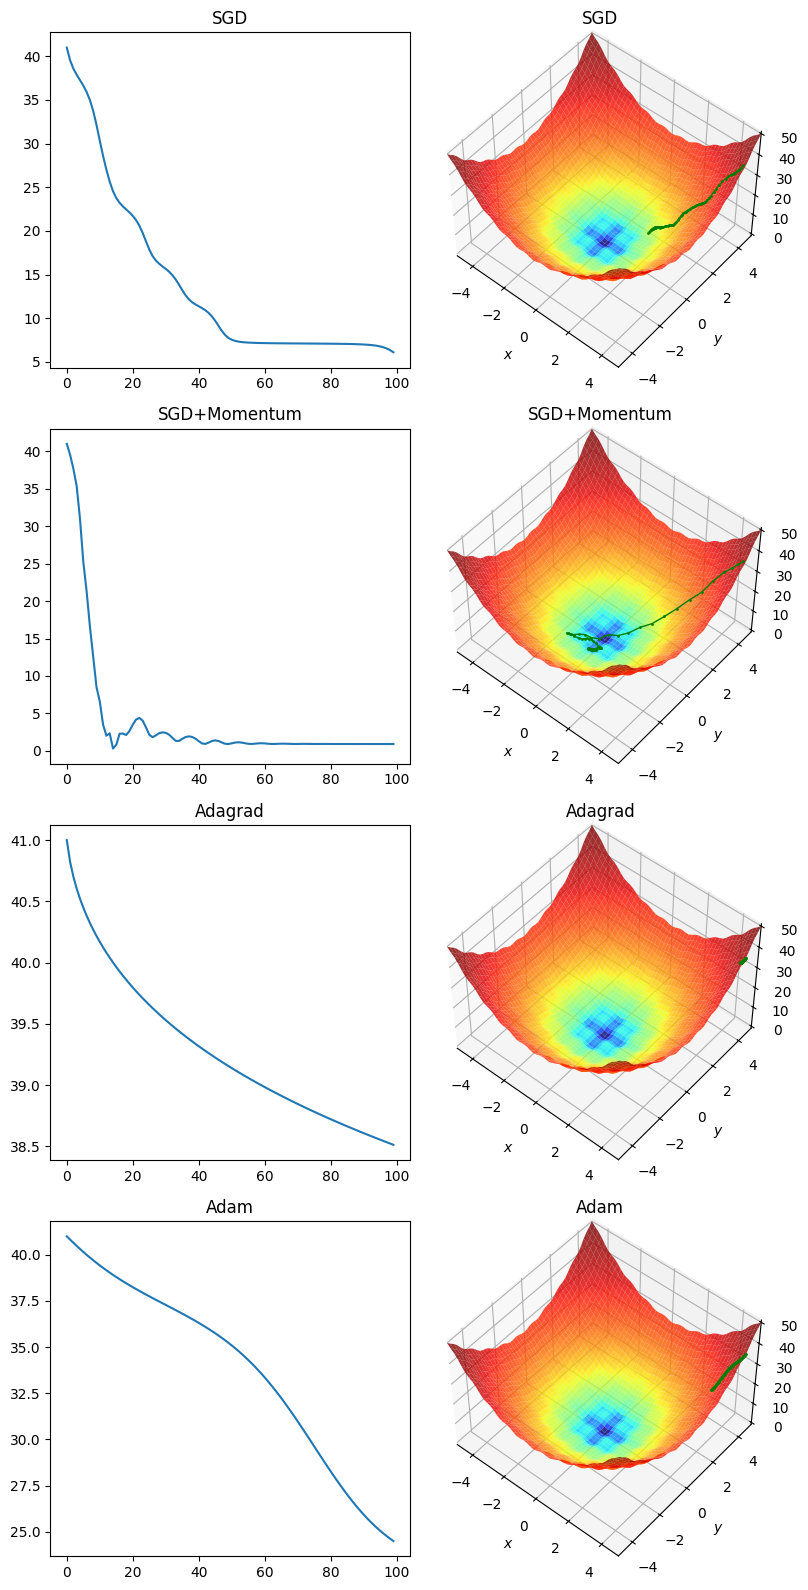

In [37]:
from torch.optim import SGD, Adagrad, Adam
from functools import partial

xmin, xmax, xstep = -5, 5, .2
ymin, ymax, ystep = -5, 5, .2
x, y = np.meshgrid(np.arange(xmin, xmax + xstep, xstep), np.arange(ymin, ymax + ystep, ystep))
z = rastring2D(torch.tensor([x, y]), 0.5).numpy()
fig = plt.figure(figsize=(8, 16))

##### Optimisation #####
optimisers = {
    'SGD': partial(SGD, lr=0.01),
    'SGD+Momentum': partial(SGD, lr=0.01, momentum=0.9),
    'Adagrad': partial(Adagrad, lr=0.01),
    'Adam': partial(Adam, lr=0.01)
}

i = 1
for name, optimiser in optimisers.items():
  values, path = optimise_with(optimiser, num_epochs=100)

  #### Plot #####
  ax = fig.add_subplot(4, 2, i)
  i+=1
  ax.plot(values)
  ax.set_title(name)
  ax = fig.add_subplot(4, 2, i, projection='3d')
  i+=1

  # Set the viewing angle for each subplot
  ax.view_init(elev=50, azim=-50)

  # Plot the 3D surface
  ax.plot_surface(x, y, z, norm=LogNorm(), rstride=1, cstride=1,edgecolor='none', alpha=.8, cmap=plt.cm.jet)

  # path
  path_x = np.array([p[0] for p in path])
  path_y = np.array([p[1] for p in path])
  ax.plot(path_x, path_y, values, color='green', linewidth=1, marker='o', markersize=1, zorder=10)
  ax.set_title(name)
  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_zlabel('$z$')
  ax.set_xlim((xmin, xmax))
  ax.set_ylim((ymin, ymax))
plt.tight_layout()
plt.show()

# 2 Optimisation of a SVM on real data

In [38]:
import torch
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
df = df.sample(frac=1) # shuffle

df = df[df[4].isin(['Iris-virginica', 'Iris-versicolor'])] # filter

# add label indices column
mapping = {k: v for v, k in enumerate(df[4].unique())}
df[5] = (2*df[4].map(mapping)) - 1 # labels in {-1,1}

# normalise data
alldata = torch.tensor(df.iloc[:, [0,1,2,3]].values, dtype=torch.float)
alldata = (alldata - alldata.mean(dim=0)) / alldata.var(dim=0)

# create datasets
targets_tr = torch.tensor(df.iloc[:75, 5].values, dtype=torch.long)
targets_va = torch.tensor(df.iloc[75:, 5].values, dtype=torch.long)

data_tr = alldata[:75]
data_va = alldata[75:]

In [39]:
print(targets_tr)

tensor([-1,  1, -1,  1,  1,  1, -1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,
        -1,  1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1,  1,
         1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
        -1, -1,  1,  1, -1, -1,  1,  1,  1, -1, -1, -1, -1,  1,  1, -1,  1,  1,
        -1,  1,  1])


In [40]:
def hinge_loss(y_pred, y_true):
    ones = torch.ones(y_true.shape)
    diff = ones - (y_pred*y_true)
    return diff[diff > 0].sum() / ones.sum()

def svm(x, w, b):
    h = (w*x).sum(1) + b
    return h

def optimise_with(optimiser_recipe, num_epochs=100):
  w = torch.randn((4), requires_grad=True)
  b = torch.randn((1), requires_grad=True)

  optimiser = optimiser_recipe([w])

  batch_size = 25
  for i in range(num_epochs):
    for batch_i in range(0, data_tr.shape[0], batch_size):
      batch_x = data_tr[batch_i:batch_i+25]
      batch_y = targets_tr[batch_i:batch_i+25]

      optimiser.zero_grad()
      loss = hinge_loss(svm(batch_x, w, b), batch_y)
      loss.backward()
      optimiser.step()

  return w.data, b.data

def accuracy(y_pred, y_true):
  return (y_pred == y_true).float().mean()


optimisers = {
    'SGD-0.01': partial(SGD, lr=0.01, weight_decay=0.0001),
    'SGD-0.001': partial(SGD, lr=0.001, weight_decay=0.0001),
    'SGD-0.0001': partial(SGD, lr=0.0001, weight_decay=0.0001),
    'Adam-0.01': partial(Adam, lr=0.01, weight_decay=0.0001),
    'Adam-0.001': partial(Adam, lr=0.001, weight_decay=0.0001),
    'Adam-0.0001': partial(Adam, lr=0.0001, weight_decay=0.0001)
}

accs = {}
for name, optimiser in optimisers.items():
  w, b = optimise_with(optimiser, num_epochs=100)

  # preditc
  preds = svm(data_va, w, b)
  preds[preds > 0] = 1
  preds[preds <= 0] = -1

  acc = accuracy(preds, targets_va)
  print(f"Accuracy for {name}: {acc}")

  model_name = name.split('-')[0]
  if not model_name in accs.keys():
    accs[model_name] = [acc]
  else:
    accs[model_name].append(acc)

print("---------")
for name, acc_values in accs.items():
  print(f"optimiser: {name}")
  mean = sum(acc_values) / len(acc_values)
  print(f" expected accuracy: {mean}")
  var = sum([(value - mean)**2 for value in acc_values]) / len(acc_values)
  print(f" accuracy variance: {var}")


Accuracy for SGD-0.01: 0.8399999737739563
Accuracy for SGD-0.001: 0.2800000011920929
Accuracy for SGD-0.0001: 0.9200000166893005
Accuracy for Adam-0.01: 0.9599999785423279
Accuracy for Adam-0.001: 0.2800000011920929
Accuracy for Adam-0.0001: 0.4399999976158142
---------
optimiser: SGD
 expected accuracy: 0.6800000071525574
 accuracy variance: 0.08106666803359985
optimiser: Adam
 expected accuracy: 0.5600000023841858
 accuracy variance: 0.08426666259765625
